In [1]:
from dinosaw import PEModel
from dinosaw.utils import load_image, normalize, resize_crop, do_2D_pca, convert_image
from dinosaw.models.vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_LIST,
)
import matplotlib.pyplot as plt
import cv2
import torch
from torchvision.transforms.functional import to_pil_image

/home/pawlo/miniforge3/envs/england_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=False, device="cuda").half()

torch.Size([3, 1009, 933])


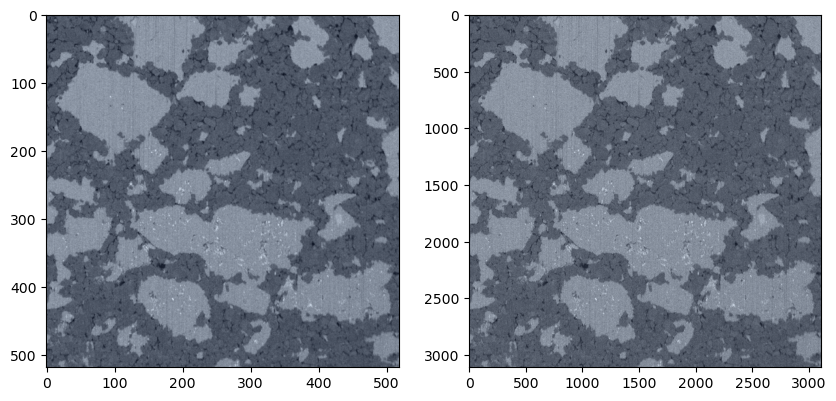

In [3]:
img_size = 1*518
mult_big=6

slice_in = torch.tensor(cv2.imread("images/slice-In-Beam BSE-00184.png", cv2.IMREAD_GRAYSCALE)).repeat(3,1,1)
print(slice_in.shape)
test_img_small = convert_image(to_pil_image(slice_in), transform=resize_crop((img_size, img_size), (img_size, img_size)))
test_img_big = convert_image(to_pil_image(slice_in), transform=resize_crop((img_size*mult_big, img_size*mult_big), (img_size*mult_big, img_size*mult_big)))
#test_img_small = load_image("images/default_image.jpg", resize_crop((img_size, img_size), (img_size, img_size)))[0]
# test_img_big = load_image("images/default_image.jpg", resize_crop((img_size*mult_big, img_size*mult_big), (img_size*mult_big, img_size*mult_big)))[0]



fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(normalize(test_img_small.cpu().squeeze().permute(1,2,0).float()))
ax[1].imshow(normalize(test_img_big.cpu().squeeze().permute(1,2,0).float()))

In [4]:
res_small = vit_wrapper.forward_features(test_img_small, make_2D=True)
res_big = vit_wrapper.forward_features(test_img_big, make_2D=True)

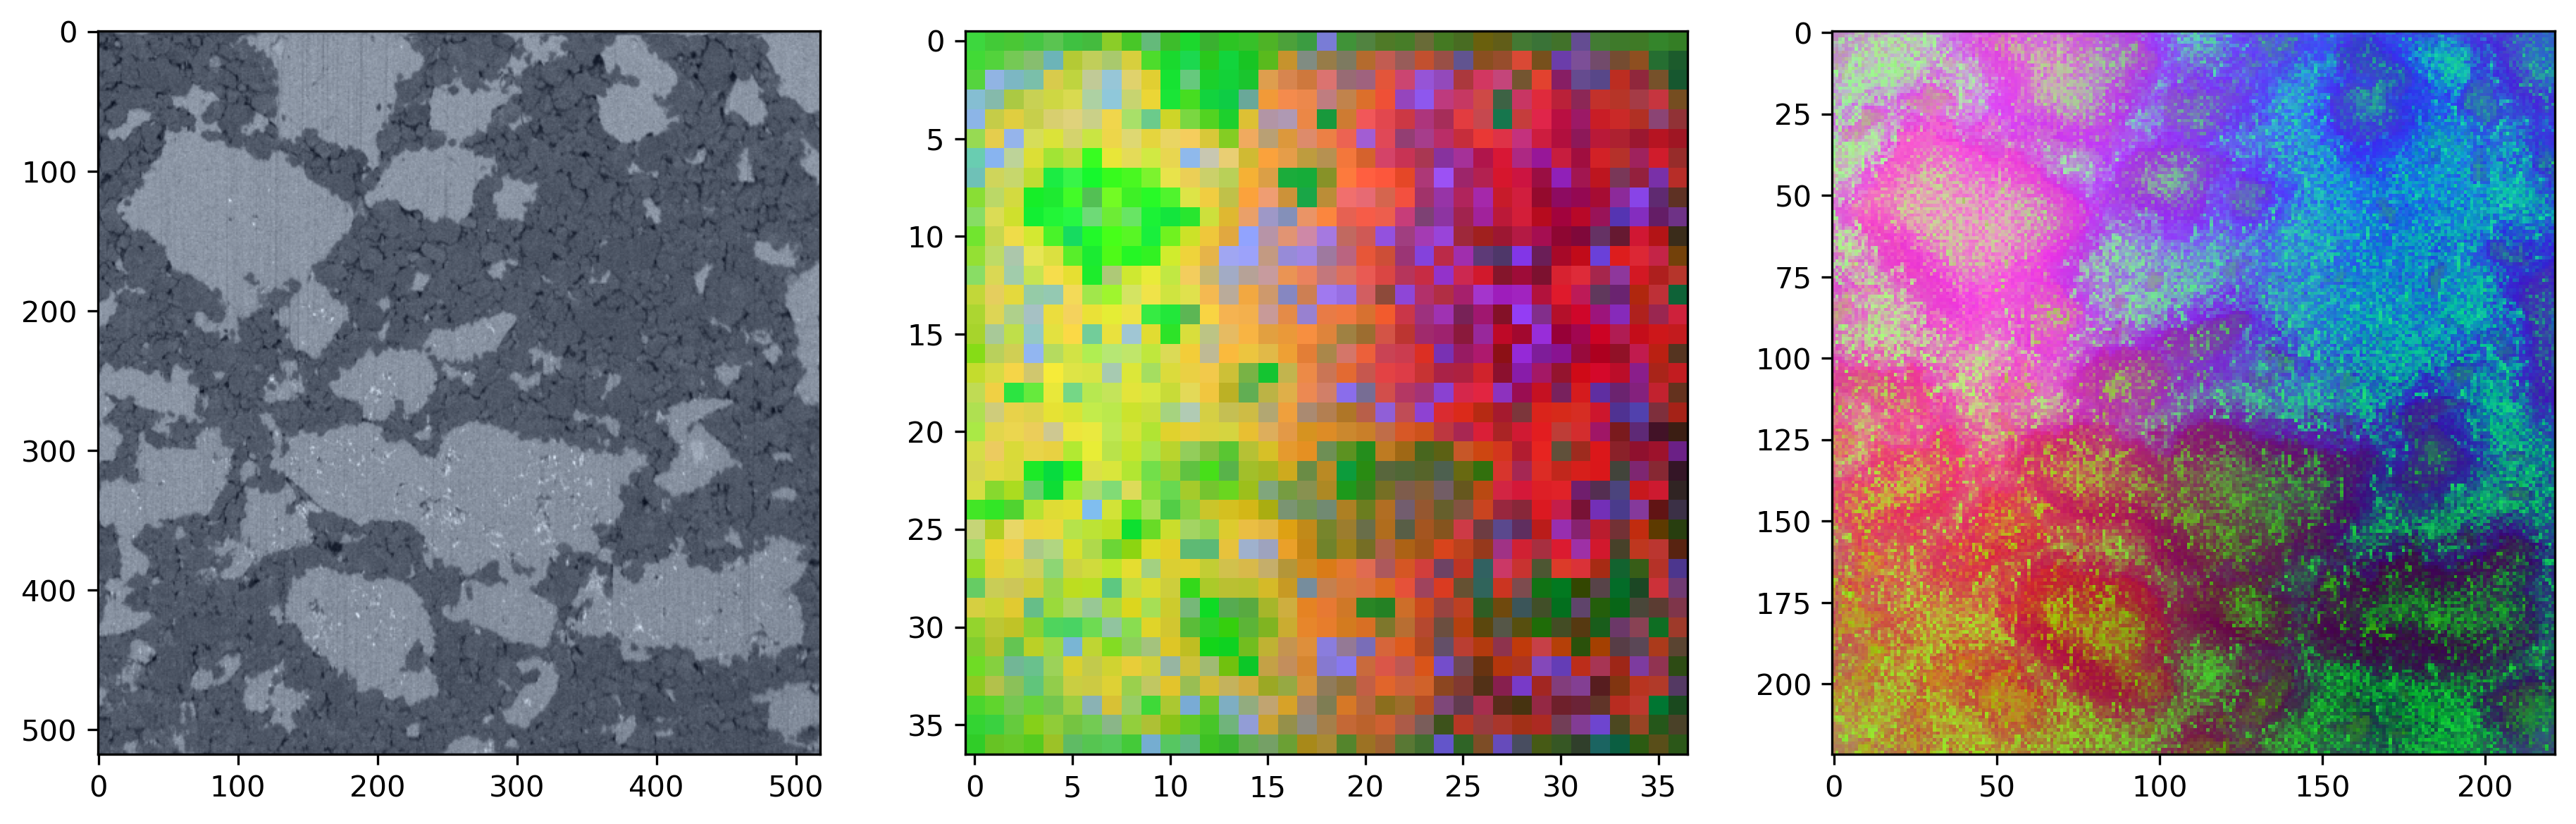

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

ax[0].imshow(normalize(test_img_small.cpu().squeeze().permute(1,2,0).float()))
ax[1].imshow(do_2D_pca(res_small.squeeze(), post_norm="minmax"))
ax[2].imshow(do_2D_pca(res_big.squeeze(), post_norm="minmax"))